# TD-4 Feature Engineering and PCA (Palmer Penguins Dataset)

This practical session is based on **CM4**.  
The goal is to practice **feature creation**, **feature transformation**, and **principal component analysis (PCA)**.

We will not build a classifier in this lab.  
The main goal is to understand how to transform raw data into numerical representations and then reduce their dimension.

## Session plan

During this session, you will work through the following steps:

1. Load and inspect a simple real dataset  
2. Perform basic cleaning  
3. Create new numerical features  
4. Transform numerical and categorical variables  
5. Prepare numerical data for PCA  
6. Apply PCA with scikit-learn  
7. Choose the number of components using explained variance  
8. Manually implement PCA using covariance, eigenvalues, and eigenvectors  
9. Compare manual PCA with scikit-learn PCA

### Expected work
For each exercise:
- read the question carefully;
- write the requested code;
- when asked, add a short comment to explain your interpretation.

### Important rules
- Do not modify the original dataframe directly.
- Keep the `species` variable only for interpretation and visualization.
- Standardize numerical features before PCA.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme()


## Part 0 — Load the dataset

We use the **Palmer Penguins** dataset.

Each row represents **one penguin**. The dataset contains:
- a species label;
- categorical variables such as island and sex;
- numerical measurements such as bill length, bill depth, flipper length, and body mass.

### Tasks
1. Load the dataset into a dataframe called `penguins_df`.
2. Display the first 5 rows.
3. Display the shape of the dataset.
4. Create a second dataframe called `df` that will be used during the lab.

### Important note
The variable `species` will be used only for interpretation and visualization.  
It must not be used as an input variable for PCA.

In [2]:
# The dataset is available through seaborn.
# The fallback URL is useful in case sns.load_dataset does not work in your environment.

try:
    penguins_df = sns.load_dataset("penguins")
except Exception:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
    penguins_df = pd.read_csv(url)

penguins_df.head()
penguins_df.shape

df = penguins_df.copy()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


(344, 7)

## Part 1 — First inspection of the dataset

Before creating new features, we need to understand the raw variables.

### Tasks
1. Display general information about `df`.
2. Show the data types of all columns.
3. Count missing values in each column.
4. Display descriptive statistics for numerical columns.
5. Display descriptive statistics for categorical columns.
6. Answer briefly: which variables are numerical? Which variables are categorical?

In [3]:
df.info()

df.dtypes

missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

df.describe()

df.describe(include="object")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

sex                  11
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
species               0
island                0
dtype: int64

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


**Short comment:**  
The numerical variables are mainly `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`.  
The categorical variables are `species`, `island`, and `sex`.  
The variable `year` is numerical in storage, but it is better interpreted as a time/context variable rather than a body measurement.

## Part 2 — Basic cleaning

For this lab, the goal is not to study missing-value imputation.  
We will keep the cleaning step simple and remove rows with missing values.

### Tasks
1. Count how many rows contain at least one missing value.
2. Create a clean dataframe called `df_clean` by removing missing values.
3. Check the new shape.
4. Check that no missing values remain.

### Question
Why is it acceptable here to use `dropna()`?

In [4]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing

df_clean = df.dropna().copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

df_clean.isna().sum()


11

Original shape: (344, 7)
Clean shape: (333, 7)


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

**Answer:**  
It is acceptable here because the dataset is small but still keeps enough observations after removing missing rows.  
The purpose of this lab is feature engineering and PCA, not a detailed comparison of imputation strategies.

## Part 2b — Quick visual inspection

Before engineering features, we inspect some numerical variables.

### Tasks
1. Plot the distribution of `body_mass_g`.
2. Plot the distribution of `bill_length_mm`.
3. Draw a scatter plot of `bill_length_mm` versus `bill_depth_mm`, colored by `species`.
4. Write a short comment: do species seem to differ in these measurements?

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='body_mass_g', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of body mass')

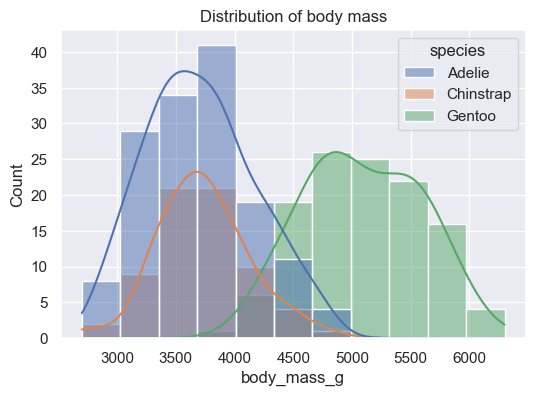

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='bill_length_mm', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of bill length')

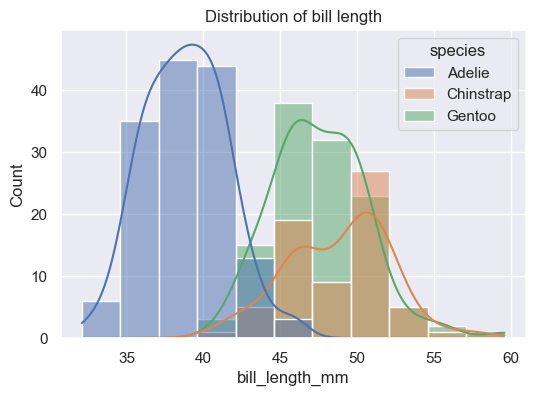

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

Text(0.5, 1.0, 'Bill length vs bill depth')

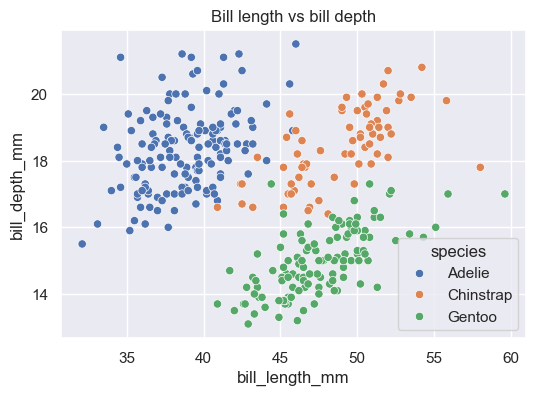

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_clean, x="body_mass_g", hue="species", kde=True)
plt.title("Distribution of body mass")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df_clean, x="bill_length_mm", hue="species", kde=True)
plt.title("Distribution of bill length")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)
plt.title("Bill length vs bill depth")
plt.show()


**Short comment:**  
The species do not have exactly the same distributions.  
For example, bill length and bill depth already show visible differences between some species.  
This suggests that these numerical measurements contain useful structure.

## Part 3 — Feature creation

Feature creation means creating new variables from existing variables.

In this part, we create simple, interpretable features from the raw penguin measurements.

### Tasks
Create the following features in a dataframe called `df_fe`:

1. `body_mass_kg`: body mass in kilograms.
2. `bill_ratio`: bill length divided by bill depth.
3. `bill_area_proxy`: bill length multiplied by bill depth.
4. `flipper_length_per_kg`: flipper length divided by body mass in kg.

### Questions
1. Which feature is only a unit conversion?
2. Which features are ratio features?
3. Are all created features necessarily useful?

In [6]:
df_fe = df_clean.copy()

df_fe["body_mass_kg"] = df_fe["body_mass_g"] / 1000

df_fe["bill_ratio"] = (
    df_fe["bill_length_mm"] / df_fe["bill_depth_mm"]
)

df_fe["bill_area_proxy"] = (
    df_fe["bill_length_mm"] * df_fe["bill_depth_mm"]
)

df_fe["flipper_length_per_kg"] = (
    df_fe["flipper_length_mm"] / df_fe["body_mass_kg"]
)

df_fe[
    [
        "body_mass_g",
        "body_mass_kg",
        "bill_length_mm",
        "bill_depth_mm",
        "bill_ratio",
        "bill_area_proxy",
        "flipper_length_mm",
        "flipper_length_per_kg",
    ]
].head()


,body_mass_g,body_mass_kg,bill_length_mm,bill_depth_mm,bill_ratio,bill_area_proxy,flipper_length_mm,flipper_length_per_kg
0,3750.0,3.75,39.1,18.7,2.090909,731.17,181.0,48.266667
1,3800.0,3.80,39.5,17.4,2.270115,687.30,186.0,48.947368
2,3250.0,3.25,40.3,18.0,2.238889,725.40,195.0,60.000000
4,3450.0,3.45,36.7,19.3,1.901554,708.31,193.0,55.942029
5,3650.0,3.65,39.3,20.6,1.907767,809.58,190.0,52.054795


**Answer:**  
`body_mass_kg` is only a unit conversion.  
`bill_ratio` and `flipper_length_per_kg` are ratio features.  
Not all created features are necessarily useful: some may be redundant with existing variables or may not help the analysis.

## Part 3b — Inspect the created features

After creating features, we should inspect them.

### Tasks
1. Display descriptive statistics for the new features.
2. Plot the distribution of `bill_ratio`.
3. Plot the distribution of `flipper_length_per_kg`.
4. Compute the correlation matrix of the original and created numerical features.

### Question
Do some variables seem redundant?

,body_mass_kg,bill_ratio,bill_area_proxy,flipper_length_per_kg
count,333.000000,333.000000,333.000000,333.000000
mean,4.207057,2.607228,752.675646,48.948298
std,0.805216,0.495436,115.897612,6.582031
min,2.700000,1.639810,497.550000,35.079365
25%,3.550000,2.162651,669.600000,43.958333
50%,4.050000,2.576531,731.600000,48.750000
75%,4.775000,3.096970,808.500000,53.157895
max,6.300000,3.612676,1127.360000,71.111111


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='bill_ratio', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of bill_ratio')

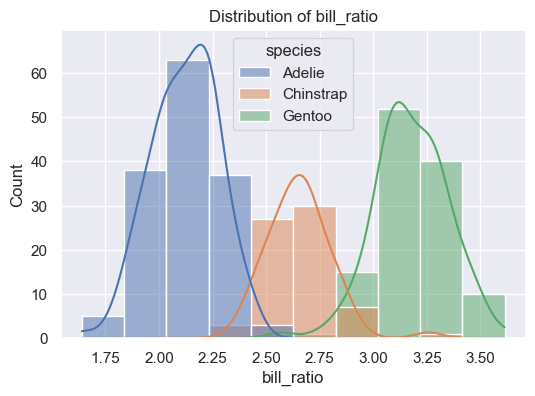

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='flipper_length_per_kg', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of flipper_length_per_kg')

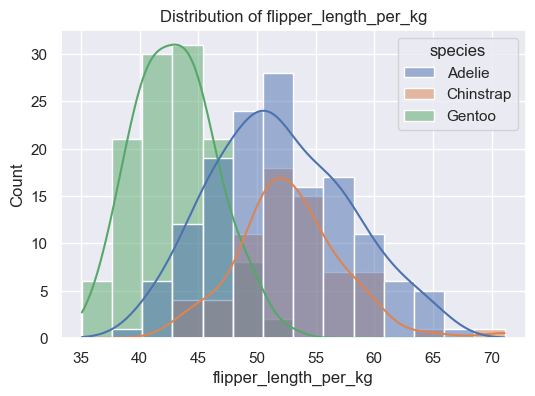

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,body_mass_kg,bill_ratio,bill_area_proxy,flipper_length_per_kg
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,0.589451,0.779230,0.661467,-0.485285
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,-0.472016,-0.781246,0.575513,0.325971
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.872979,0.801980,0.086512,-0.683370
body_mass_g,0.589451,-0.472016,0.872979,1.000000,1.000000,0.702179,0.104220,-0.938924
body_mass_kg,0.589451,-0.472016,0.872979,1.000000,1.000000,0.702179,0.104220,-0.938924
bill_ratio,0.779230,-0.781246,0.801980,0.702179,0.702179,1.000000,0.048658,-0.550113
bill_area_proxy,0.661467,0.575513,0.086512,0.104220,0.104220,0.048658,1.000000,-0.127212
flipper_length_per_kg,-0.485285,0.325971,-0.683370,-0.938924,-0.938924,-0.550113,-0.127212,1.000000


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation matrix')

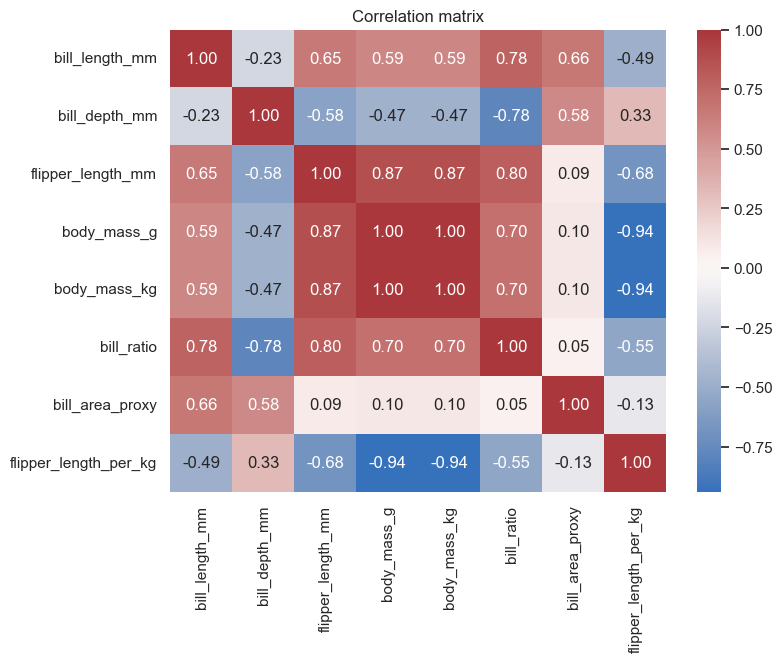

In [7]:
created_cols = [
    "body_mass_kg",
    "bill_ratio",
    "bill_area_proxy",
    "flipper_length_per_kg"
]

df_fe[created_cols].describe()

plt.figure(figsize=(6, 4))
sns.histplot(data=df_fe, x="bill_ratio", hue="species", kde=True)
plt.title("Distribution of bill_ratio")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df_fe, x="flipper_length_per_kg", hue="species", kde=True)
plt.title("Distribution of flipper_length_per_kg")
plt.show()

num_for_corr = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "body_mass_kg",
    "bill_ratio",
    "bill_area_proxy",
    "flipper_length_per_kg",
]

corr = df_fe[num_for_corr].corr()
corr

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix")
plt.show()


**Short comment:**  
Some variables are clearly redundant by construction.  
For example, `body_mass_kg` is perfectly correlated with `body_mass_g` because it is only a unit conversion.  
`bill_area_proxy` is also strongly related to bill length and bill depth because it is computed from them.

## Part 4 — Feature transformation

Feature transformation changes the representation of variables.

In this part, we practice two simple transformations:
- a logarithmic transformation for a numerical variable;
- one-hot encoding for categorical variables.

### Tasks
1. Create `log_body_mass` using `np.log1p(body_mass_g)`.
2. One-hot encode `island` and `sex`.
3. Compare the shape before and after one-hot encoding.
4. Answer briefly: why does one-hot encoding increase the number of columns?

In [8]:
df_transformed = df_fe.copy()

df_transformed["log_body_mass"] = np.log1p(df_transformed["body_mass_g"])

df_encoded = pd.get_dummies(
    df_transformed,
    columns=["island", "sex"],
    drop_first=False
)

print("Shape before one-hot encoding:", df_transformed.shape)
print("Shape after one-hot encoding:", df_encoded.shape)

dummy_cols = [
    col for col in df_encoded.columns
    if col.startswith("island_") or col.startswith("sex_")
]

df_encoded[dummy_cols].head()


Shape before one-hot encoding: (333, 12)
Shape after one-hot encoding: (333, 15)


,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
0,False,False,True,False,True
1,False,False,True,True,False
2,False,False,True,True,False
4,False,False,True,True,False
5,False,False,True,False,True


**Answer:**  
One-hot encoding increases the number of columns because each category is represented by a separate binary indicator.  
For example, one variable such as `island` becomes several columns such as `island_Biscoe`, `island_Dream`, and `island_Torgersen`.

## Part 5 — Prepare numerical features for PCA

PCA requires numerical input variables.  
In this lab, we will use only numerical measurements and engineered numerical features.

The species label will be used only to color the final PCA plot.

### Tasks
1. Define a list called `pca_features`.
2. Create a matrix `X` containing only these numerical columns.
3. Display descriptive statistics.
4. Explain why `species` should not be included in `X`.

In [9]:
pca_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_kg",
    "bill_ratio",
    "bill_area_proxy",
    "flipper_length_per_kg",
]

X = df_transformed[pca_features].copy()

X.shape
X.describe().T


(333, 7)

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,333.0,43.992793,5.468668,32.100000,39.500000,44.500000,48.600000,59.600000
bill_depth_mm,333.0,17.164865,1.969235,13.100000,15.600000,17.300000,18.700000,21.500000
flipper_length_mm,333.0,200.966967,14.015765,172.000000,190.000000,197.000000,213.000000,231.000000
body_mass_kg,333.0,4.207057,0.805216,2.700000,3.550000,4.050000,4.775000,6.300000
bill_ratio,333.0,2.607228,0.495436,1.639810,2.162651,2.576531,3.096970,3.612676
bill_area_proxy,333.0,752.675646,115.897612,497.550000,669.600000,731.600000,808.500000,1127.360000
flipper_length_per_kg,333.0,48.948298,6.582031,35.079365,43.958333,48.750000,53.157895,71.111111


**Answer:**  
`species` should not be included in `X` because PCA is an unsupervised method.  
We use `species` only after PCA to interpret whether the two-dimensional projection reveals species-related structure.

## Part 6 — PCA: what are the steps?

PCA creates new variables called **principal components**.  
Each principal component is a linear combination of the original numerical variables.

For a numerical data matrix $X$, the main steps are:

1. **Select numerical features**  
   Keep only the variables that can be used in PCA.

2. **Center the data**  
   For each feature, subtract its mean:
   $$
   x^{c}_{ij} = x_{ij} - \bar{x}_j
   $$

3. **Scale the data**  
   If variables have different units or different scales, divide each feature by its standard deviation:
   $$
   x^{s}_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}
   $$

4. **Compute the covariance matrix**
   $$
   S = \frac{1}{n-1}(X^s)^T X^s
   $$

5. **Find eigenvalues and eigenvectors**
   $$
   S w_j = \lambda_j w_j
   $$
   The eigenvectors give the PCA directions.  
   The eigenvalues give the variance captured by each direction.

6. **Sort components by decreasing eigenvalue**

7. **Project the data**
   If $W_k$ contains the first $k$ eigenvectors, then:
   $$
   Z_k = X^s W_k
   $$

8. **Interpret explained variance**
   $$
   \text{Explained variance ratio of PC } j =
   \frac{\lambda_j}{\lambda_1 + \cdots + \lambda_p}
   $$

In practice, we usually use `StandardScaler` followed by `PCA` from scikit-learn.  
Then we implement the same logic manually to understand what happens.

## Part 7 — Centering and scaling before PCA

PCA is based on variance, so variables with larger numerical scales can dominate the result.

### Tasks
1. Use `StandardScaler` to center and scale `X`.
2. Store the result in `X_scaled`.
3. Convert `X_scaled` to a dataframe called `X_scaled_df`.
4. Check that the scaled variables have mean close to 0 and standard deviation close to 1.

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=pca_features,
    index=X.index
)

X_scaled_df.mean().round(3)
X_scaled_df.std(ddof=0).round(3)


bill_length_mm           0.0
bill_depth_mm            0.0
flipper_length_mm        0.0
body_mass_kg            -0.0
bill_ratio               0.0
bill_area_proxy         -0.0
flipper_length_per_kg    0.0
dtype: float64

bill_length_mm           1.0
bill_depth_mm            1.0
flipper_length_mm        1.0
body_mass_kg             1.0
bill_ratio               1.0
bill_area_proxy          1.0
flipper_length_per_kg    1.0
dtype: float64

## Part 8 — PCA with scikit-learn

We now apply PCA with scikit-learn.

### Tasks
1. Create a PCA object with `n_components=2`.
2. Fit PCA on the scaled data and transform the data.
3. Store the PCA scores in a dataframe called `pca_df`.
4. Add the `species` column to `pca_df` for visualization only.
5. Display the explained variance ratio of PC1 and PC2.
6. Display the loadings of the original variables on PC1 and PC2.

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df["species"] = df_transformed.loc[X.index, "species"].values

explained = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_)
})

explained

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1", "PC2"]
)

loadings


,component,explained_variance,explained_variance_ratio,cumulative_ratio
0,PC1,4.233113,0.602914,0.602914
1,PC2,1.771219,0.252271,0.855186


,PC1,PC2
bill_length_mm,0.377052,0.390340
bill_depth_mm,-0.308431,0.536277
flipper_length_mm,0.449966,-0.034266
body_mass_kg,0.450171,0.007005
bill_ratio,0.444567,-0.095442
bill_area_proxy,0.071246,0.739641
flipper_length_per_kg,-0.393526,-0.051395


**Short comment:**  
The explained variance ratio tells us how much of the total variance is retained by each principal component.  
The loadings show how strongly each original variable contributes to each component.

## Part 8b — Visualize the PCA projection

A common use of PCA is to visualize high-dimensional numerical data in 2D.

### Tasks
1. Make a scatter plot of `PC1` and `PC2`.
2. Color the points by `species`.
3. Answer briefly:
   - Do the species form visible groups?
   - Does PCA use the species labels to find PC1 and PC2?

<Figure size 700x500 with 0 Axes>

<Axes: xlabel='PC1', ylabel='PC2'>

Text(0.5, 1.0, 'PCA projection of penguins')

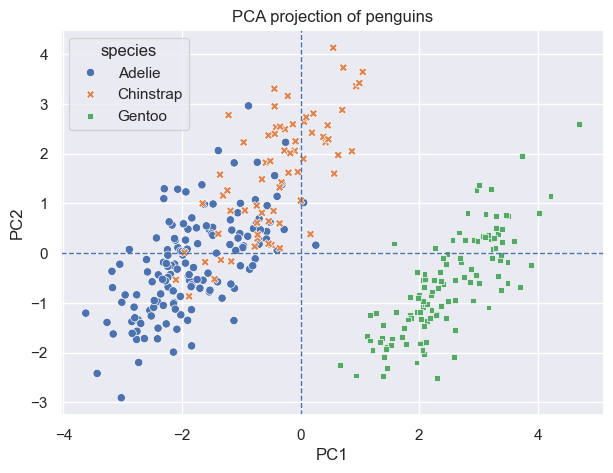

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    style="species"
)
plt.title("PCA projection of penguins")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.show()


**Answer:**  
The species often form visible groups in the PCA space, especially because the body measurements differ across species.  
However, PCA does not use the species labels to compute PC1 and PC2.  
The labels are added only after PCA to help interpret the plot.

## Part 9 — Choosing the number of components

Using only 2 components is useful for visualization, but it may not preserve enough variance.

### Tasks
1. Fit PCA with all components.
2. Compute the cumulative explained variance.
3. Plot the cumulative explained variance.
4. Find the smallest number of components that keeps at least 90% of the variance.

<Figure size 600x400 with 0 Axes>

Text(0.5, 0, 'Number of components')

Text(0, 0.5, 'Cumulative explained variance')

Text(0.5, 1.0, 'Cumulative explained variance')

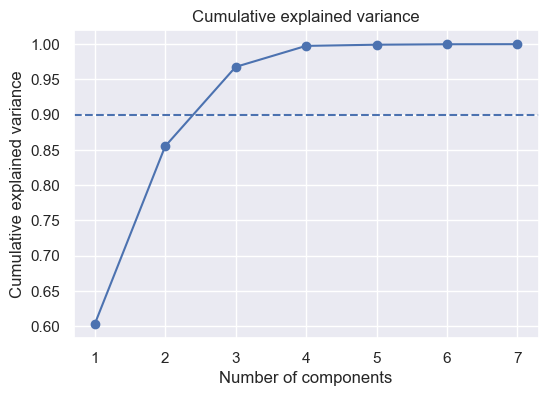

3

In [13]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.show()

k_90 = np.argmax(cum_var >= 0.90) + 1
k_90


**Short comment:**  
The value of `k_90` is the smallest number of principal components needed to retain at least 90% of the total variance.  
This value may be larger than 2, because two dimensions are chosen mainly for visualization.

## Part 10 — Manual PCA implementation

We now implement PCA manually.

The goal is to reproduce the main results of scikit-learn:
- the covariance matrix;
- eigenvalues and eigenvectors;
- explained variance ratios;
- projection onto the first two principal components.

### Important note
Eigenvectors can have arbitrary sign.  
If a component from the manual implementation is the negative of the scikit-learn component, it is not an error.

### Step 1 — Manually center and scale the data

### Tasks
1. Compute the mean of each feature.
2. Compute the standard deviation of each feature.
3. Create `X_manual_scaled`.
4. Check the mean and standard deviation after scaling.

In [14]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)

X_manual_scaled = (X - X_mean) / X_std

X_manual_scaled.mean().round(3)
X_manual_scaled.std(ddof=0).round(3)


bill_length_mm           0.0
bill_depth_mm            0.0
flipper_length_mm        0.0
body_mass_kg            -0.0
bill_ratio              -0.0
bill_area_proxy         -0.0
flipper_length_per_kg    0.0
dtype: float64

bill_length_mm           1.0
bill_depth_mm            1.0
flipper_length_mm        1.0
body_mass_kg             1.0
bill_ratio               1.0
bill_area_proxy          1.0
flipper_length_per_kg    1.0
dtype: float64

### Step 2 — Compute the covariance matrix

### Tasks
1. Compute the covariance matrix of the manually scaled data.
2. Store it in a variable called `S`.
3. Display its shape.
4. Display the covariance matrix as a dataframe.

In [15]:
S = np.cov(X_manual_scaled, rowvar=False)

S.shape

S_df = pd.DataFrame(
    S,
    index=pca_features,
    columns=pca_features
)

S_df


(7, 7)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_kg,bill_ratio,bill_area_proxy,flipper_length_per_kg
bill_length_mm,1.003012,-0.229314,0.655063,0.591227,0.781577,0.663460,-0.486747
bill_depth_mm,-0.229314,1.003012,-0.579532,-0.473437,-0.783599,0.577247,0.326953
flipper_length_mm,0.655063,-0.579532,1.003012,0.875608,0.804396,0.086773,-0.685428
body_mass_kg,0.591227,-0.473437,0.875608,1.003012,0.704294,0.104534,-0.941752
bill_ratio,0.781577,-0.783599,0.804396,0.704294,1.003012,0.048805,-0.551770
bill_area_proxy,0.663460,0.577247,0.086773,0.104534,0.048805,1.003012,-0.127595
flipper_length_per_kg,-0.486747,0.326953,-0.685428,-0.941752,-0.551770,-0.127595,1.003012


### Step 3 — Eigenvalues and eigenvectors

Because the covariance matrix is symmetric, we use `np.linalg.eigh`.

### Tasks
1. Compute eigenvalues and eigenvectors of `S`.
2. Sort them by decreasing eigenvalue.
3. Compute the explained variance ratio.
4. Compare the first ratios with scikit-learn.

In [16]:
eigenvalues, eigenvectors = np.linalg.eigh(S)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

manual_explained_variance_ratio = (
    eigenvalues_sorted / eigenvalues_sorted.sum()
)

comparison_variance = pd.DataFrame({
    "manual_ratio": manual_explained_variance_ratio[:2],
    "sklearn_ratio": pca.explained_variance_ratio_,
})

comparison_variance


,manual_ratio,sklearn_ratio
0,0.602914,0.602914
1,0.252271,0.252271


**Short comment:**  
The explained variance ratios should be the same as the scikit-learn values, up to small numerical differences.  
This confirms that both implementations follow the same PCA logic.

### Step 4 — Project the data onto the first two components

### Tasks
1. Build `W2` using the first two eigenvectors.
2. Project the scaled data onto `W2`.
3. Store the result in `manual_pca_df`.
4. Add the species labels for visualization.
5. Plot the manual PCA projection.

<Figure size 700x500 with 0 Axes>

<Axes: xlabel='PC1_manual', ylabel='PC2_manual'>

Text(0.5, 1.0, 'Manual PCA projection')

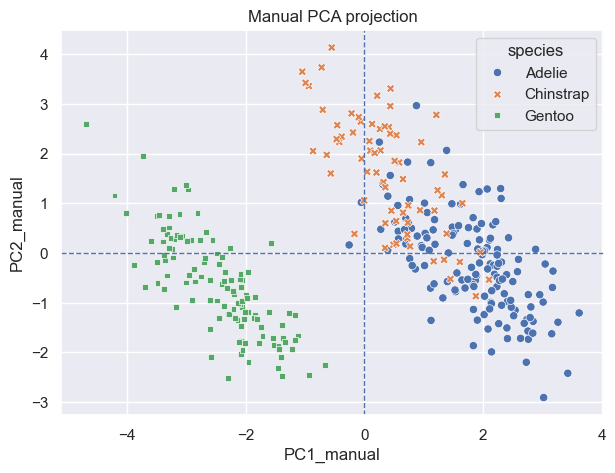

In [17]:
W2 = eigenvectors_sorted[:, :2]

X_pca_manual = X_manual_scaled.to_numpy() @ W2

manual_pca_df = pd.DataFrame(
    X_pca_manual,
    columns=["PC1_manual", "PC2_manual"],
    index=X.index
)

manual_pca_df["species"] = df_transformed.loc[X.index, "species"].values

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=manual_pca_df,
    x="PC1_manual",
    y="PC2_manual",
    hue="species",
    style="species"
)
plt.title("Manual PCA projection")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.show()


### Step 5 — Compare manual PCA and scikit-learn PCA

The sign of a principal component is arbitrary.  
Therefore, we compare components using correlation.

### Tasks
1. Compute the correlation between manual PC1 and sklearn PC1.
2. Compute the correlation between manual PC2 and sklearn PC2.
3. Interpret the result.

In [18]:
corr_pc1 = np.corrcoef(
    manual_pca_df["PC1_manual"],
    pca_df["PC1"]
)[0, 1]

corr_pc2 = np.corrcoef(
    manual_pca_df["PC2_manual"],
    pca_df["PC2"]
)[0, 1]

corr_pc1, corr_pc2


(-1.0, 0.9999999999999998)

**Answer:**  
The correlations should be close to `1` or `-1`.  
A value close to `-1` only means that the component has the opposite sign.  
This is not a problem because a PCA axis has no fixed orientation.

## Final reflection

1. **Feature creation** builds new variables from existing variables.  
   **Feature transformation** changes the representation of existing variables.

2. We standardize before PCA because PCA is based on variance.  
   Without scaling, variables with larger numerical ranges may dominate the principal components.

3. The label variable should not be used as an input because PCA is unsupervised.  
   Labels can be used after PCA for interpretation or visualization.

4. The explained variance ratio tells us the proportion of total variance captured by each principal component.

5. Feature selection keeps a subset of original variables.  
   PCA creates new variables that are linear combinations of the original variables.